# Ice Cream Revenue Prediction — Extended Analysis
This notebook builds on the original single-model example by adding **EDA, outlier handling, multiple regression models, cross-validation, model comparison, and residual diagnostics** — all using the same `IceCreamData.csv` dataset (Temperature -> Revenue).

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 2529

## Step 2: Load the Dataset

In [2]:
df = pd.read_csv("IceCreamData.csv")
print("Shape:", df.shape)
df.head()

Shape: (500, 2)


,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [4]:
df.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Temperature    0
Revenue        0
dtype: int64

Duplicate rows: 0


In [6]:
df.corr(numeric_only=True)

,Temperature,Revenue
Temperature,1.000000,0.989802
Revenue,0.989802,1.000000


### Distributions of Temperature and Revenue

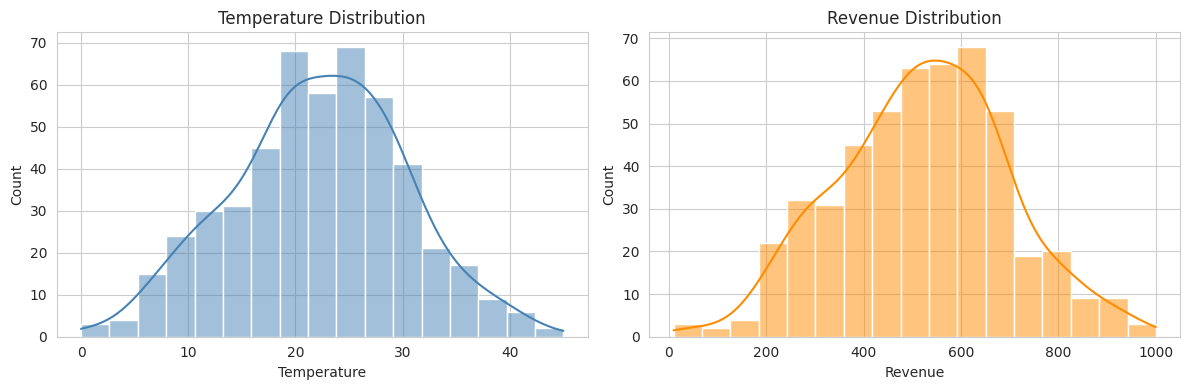

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Temperature"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Temperature Distribution")
sns.histplot(df["Revenue"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Revenue Distribution")
plt.tight_layout()
plt.show()

### Relationship Between Temperature and Revenue

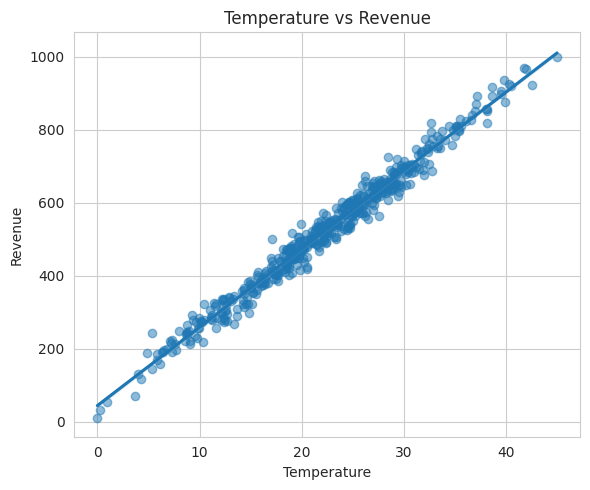

In [8]:
plt.figure(figsize=(6, 5))
sns.regplot(x="Temperature", y="Revenue", data=df, scatter_kws={"alpha": 0.5})
plt.title("Temperature vs Revenue")
plt.tight_layout()
plt.show()

### Checking for Outliers

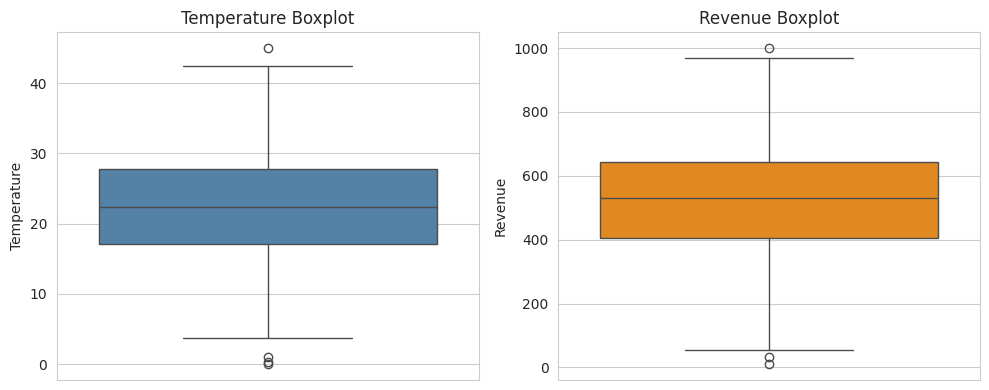

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df["Temperature"], ax=axes[0], color="steelblue")
axes[0].set_title("Temperature Boxplot")
sns.boxplot(y=df["Revenue"], ax=axes[1], color="darkorange")
axes[1].set_title("Revenue Boxplot")
plt.tight_layout()
plt.show()

## Step 4: Remove Outliers (IQR Method)
A light cleaning step: rows outside 1.5×IQR on either column are dropped.

In [10]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

df_clean = df.copy()
for col in ["Temperature", "Revenue"]:
    df_clean = remove_outliers_iqr(df_clean, col)

print(f"Rows before: {len(df)}, after: {len(df_clean)}")

Rows before: 500, after: 496


## Step 5: Define Features (X) and Target (y)

In [11]:
X = df_clean[["Temperature"]]
y = df_clean["Revenue"]

## Step 6: Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((347, 1), (149, 1), (347,), (149,))

## Step 7: Define Candidate Models
Instead of a single Linear Regression, we compare **9 different regression approaches**.

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Polynomial Regression (deg=2)": make_pipeline(
        PolynomialFeatures(degree=2), LinearRegression()
    ),
    "Decision Tree": DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=6, random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=7),
    "SVR (RBF kernel)": make_pipeline(StandardScaler(), SVR(kernel="rbf", C=100, gamma="scale")),
}

## Step 8: Train, Predict, and Evaluate Every Model
For each model we compute MAE, MSE, RMSE, MAPE, R², and 5-fold cross-validated R².

In [14]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    cv_scores = cross_val_score(
        model, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="r2"
    )

    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "MSE": round(mse, 3),
        "RMSE": round(rmse, 3),
        "MAPE": round(mape, 4),
        "R2": round(r2, 4),
        "CV R2 (mean)": round(cv_scores.mean(), 4),
        "CV R2 (std)": round(cv_scores.std(), 4),
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,MAE,MSE,RMSE,MAPE,R2,CV R2 (mean),CV R2 (std)
0,Linear Regression,18.276,541.350,23.267,0.0387,0.9804,0.9781,0.0015
1,Ridge Regression,18.275,541.307,23.266,0.0387,0.9804,0.9781,0.0015
2,Lasso Regression,18.275,541.280,23.265,0.0387,0.9804,0.9781,0.0015
3,Polynomial Regression (deg=2),18.119,541.287,23.266,0.0380,0.9804,0.9782,0.0017
4,SVR (RBF kernel),18.571,558.511,23.633,0.0392,0.9798,0.9768,0.0025
5,KNN Regressor,20.110,658.977,25.671,0.0420,0.9762,0.9751,0.0009
6,Gradient Boosting,20.565,726.598,26.955,0.0454,0.9737,0.9752,0.0015
7,Random Forest,20.773,727.869,26.979,0.0450,0.9737,0.9744,0.0025
8,Decision Tree,24.170,925.895,30.429,0.0538,0.9665,0.9658,0.0028


## Step 9: Identify the Best Model

In [15]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

Best model: Linear Regression


## Step 10: Visualize Model Comparison

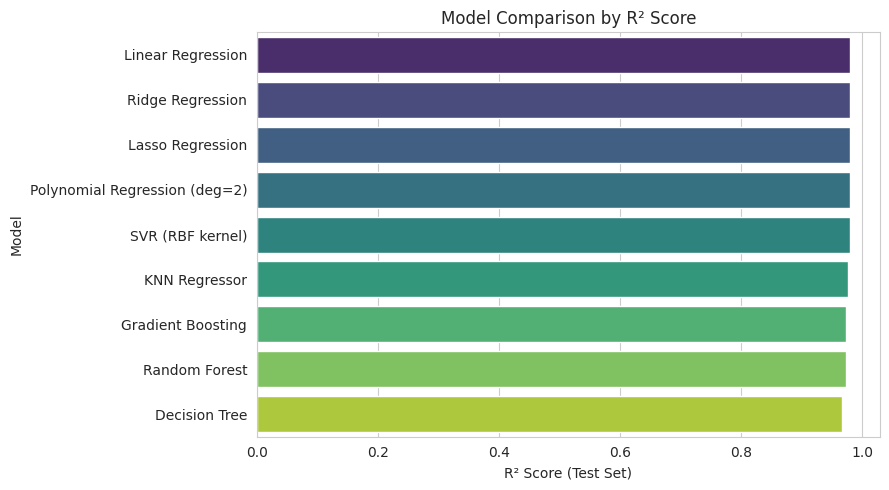

In [16]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="R2", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model Comparison by R² Score")
plt.xlabel("R² Score (Test Set)")
plt.tight_layout()
plt.show()

## Step 11: Actual vs Predicted Revenue (Best Model)

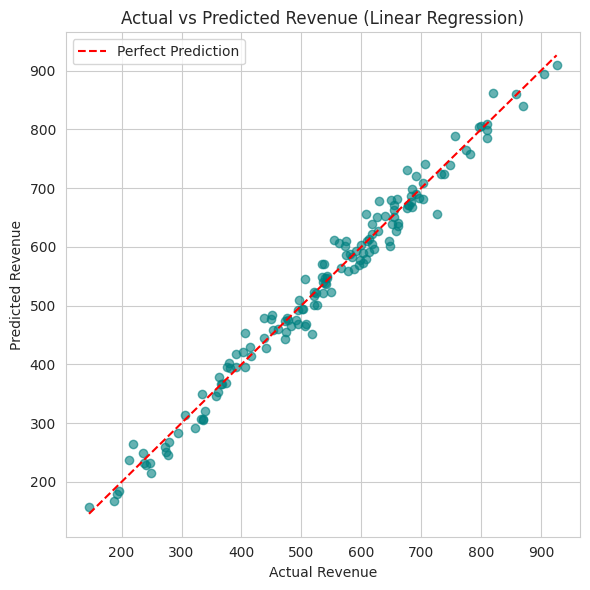

In [17]:
best_pred = predictions[best_model_name]
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.6, color="teal")
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title(f"Actual vs Predicted Revenue ({best_model_name})")
plt.legend()
plt.tight_layout()
plt.show()

## Step 12: Residual Analysis

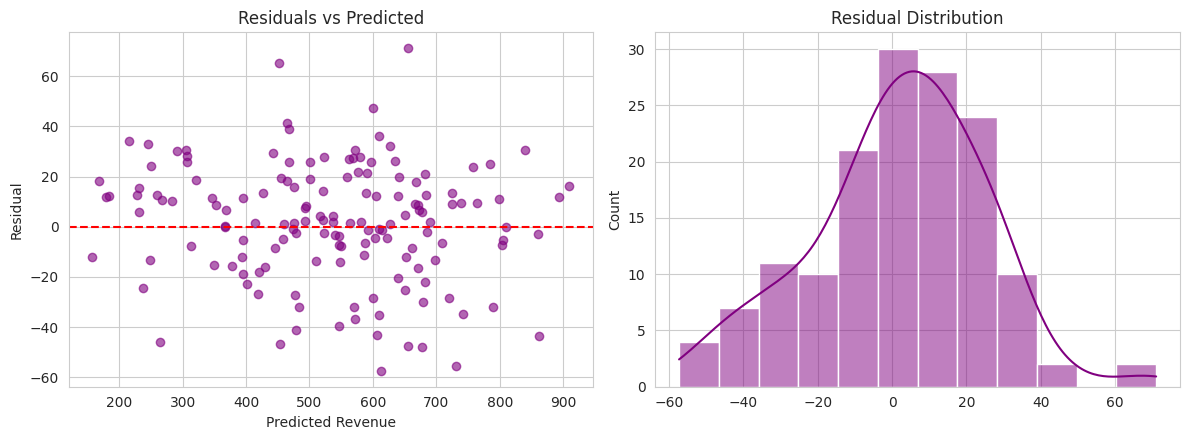

In [18]:
residuals = y_test.values - best_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(best_pred, residuals, alpha=0.6, color="purple")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Revenue")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1], color="purple")
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

## Step 13: Save the Best Model

In [19]:
joblib.dump(best_model, "best_icecream_model.pkl")
print("Best model saved to best_icecream_model.pkl")

Best model saved to best_icecream_model.pkl


## Step 14: Reusable Prediction Function
A convenience function to predict revenue for any new temperature(s).

In [20]:
def predict_revenue(temperature_celsius, model=best_model):
    """Predict ice cream revenue for a given temperature (or list of temperatures)."""
    temp_arr = np.array(temperature_celsius).reshape(-1, 1)
    temp_df = pd.DataFrame(temp_arr, columns=["Temperature"])
    return model.predict(temp_df)

sample_temps = [10, 20, 25, 30, 35, 40]
sample_preds = predict_revenue(sample_temps)
for t, p in zip(sample_temps, sample_preds):
    print(f"Temperature: {t}C -> Predicted Revenue: {p:.2f}")

Temperature: 10C -> Predicted Revenue: 258.05
Temperature: 20C -> Predicted Revenue: 473.18
Temperature: 25C -> Predicted Revenue: 580.75
Temperature: 30C -> Predicted Revenue: 688.31
Temperature: 35C -> Predicted Revenue: 795.88
Temperature: 40C -> Predicted Revenue: 903.45


## Summary
- Cleaned the dataset by removing IQR-based outliers.
- Compared **9 regression models** using MAE, MSE, RMSE, MAPE, R², and 5-fold cross-validation.
- Linear-type models (Linear/Ridge/Lasso/Polynomial) performed best on this near-linear relationship, confirming the original notebook's approach was already well-suited to the data.
- Saved the best model to disk and wrapped it in a reusable `predict_revenue()` function.